# RNN-GRU — Redes Neuronales Recurrentes con Gated Recurrent Unit

En este notebook exploramos modelos basados en arquitecturas recurrentes (GRU) para predecir la media de retornos en la ventana de salida.

Al igual que la LSTM, la GRU procesa la secuencia de entrada **paso a paso**, manteniendo un estado oculto que captura dependencias temporales. Sin embargo, la GRU simplifica la arquitectura de la LSTM utilizando **dos puertas** (reset y update) en lugar de tres, y eliminando el estado de celda separado. Esto la hace más compacta y generalmente más rápida de entrenar, con un rendimiento comparable en series temporales.

- **Entrada**: secuencia de `input_w` pasos temporales, cada uno con 23 features (retornos de los tickers).
- **Salida**: 23 valores (uno por ticker), regresión directa de la media de retornos en la ventana de salida.
- **Pérdida**: **MAE**, coherente con los notebooks anteriores (regresión lineal, MLP y LSTM).

El flujo sigue la misma estructura que `rnn-lstm.ipynb`:
1. Carga de datos (sin aplanar — se mantiene la dimensión temporal).
2. Modelo base GRU.
3. Grid de ventanas de entrada/salida.
4. Búsqueda de hiperparámetros (arquitectura y entrenamiento).
5. Comparación final contra el benchmark de regresión lineal, el MLP y la LSTM.


In [1]:
import sys
import mlflow
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

EXPERIMENT_NAME = "Red_Neuronal_Recurrente_GRU"
mlflow.set_experiment(EXPERIMENT_NAME)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import keras
from keras.models import Sequential
from keras.layers import GRU, Dense, Input, Dropout
from keras.callbacks import EarlyStopping
from keras.optimizers import Adam

from sklearn.metrics import mean_absolute_error

from util import get_train_test, RANDOM_SEED, compare_to_benchmark, plot_benchmark_comparison, plot_training_curve

np.random.seed(RANDOM_SEED)
keras.utils.set_random_seed(RANDOM_SEED)


/opt/homebrew/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026/05/01 09:52:35 INFO mlflow.tracking.fluent: Experiment with name 'Red_Neuronal_Recurrente_GRU' does not exist. Creating a new experiment.


## Carga de datos

A diferencia del MLP, **no aplanamos** la ventana de entrada. Mantenemos el tensor 3D `[samples, timesteps, features]` que espera la capa GRU:

- `timesteps` = `input_window_size` (días de historia)
- `features` = 23 (un retorno por ticker)

El split de validación (10% del train) se extrae de los últimos ejemplos, igual que en el MLP y la LSTM, para no romper el orden temporal.


In [2]:
def load_seq_data(input_window_size, output_window_size):
    """Devuelve datos con shape 3D [samples, timesteps, features] para GRU."""
    d = get_train_test(input_window_size=input_window_size, output_window_size=output_window_size)

    X_train = d.X_train  # (samples, timesteps, features) — sin aplanar
    X_test  = d.X_test
    y_train = d.y_train
    y_test  = d.y_test

    val_size = int(0.10 * X_train.shape[0])
    X_val   = X_train[-val_size:]
    y_val   = y_train[-val_size:]
    X_train = X_train[:-val_size]
    y_train = y_train[:-val_size]

    return X_train, y_train, X_val, y_val, X_test, y_test


input_window_size  = 30
output_window_size = 5

X_train_seq, y_train_seq, X_val_seq, y_val_seq, X_test_seq, y_test_seq = load_seq_data(
    input_window_size, output_window_size
)

print(f"X_train_seq: {X_train_seq.shape}  -> (samples, timesteps, features)")
print(f"y_train_seq: {y_train_seq.shape}")
print(f"X_val_seq:   {X_val_seq.shape}")
print(f"y_val_seq:   {y_val_seq.shape}")
print(f"X_test_seq:  {X_test_seq.shape}")
print(f"y_test_seq:  {y_test_seq.shape}")


X_train_seq: (13082, 30, 23)  -> (samples, timesteps, features)
y_train_seq: (13082, 23)
X_val_seq:   (1453, 30, 23)
y_val_seq:   (1453, 23)
X_test_seq:  (1616, 30, 23)
y_test_seq:  (1616, 23)


## Definición del modelo base

GRU simple: una capa recurrente con 64 unidades seguida de una capa de salida lineal.

- La capa `GRU` recibe la secuencia completa `(timesteps, features)` y devuelve únicamente el último estado oculto (`return_sequences=False`), que condensa la información temporal acumulada.
- La capa `Dense` proyecta ese estado oculto a los 23 valores de salida.

A diferencia de la LSTM, la GRU no tiene estado de celda separado, lo que reduce el número de parámetros entrenables manteniendo una capacidad de modelado similar.

Este modelo base servirá de referencia antes de explorar arquitecturas más profundas en la búsqueda de hiperparámetros.


In [3]:
num_units = 64

model = Sequential()
model.add(Input(shape=(X_train_seq.shape[1], X_train_seq.shape[2])))
model.add(GRU(num_units, return_sequences=False))
model.add(Dense(y_train_seq.shape[1]))

model.compile(loss="mean_absolute_error", optimizer="Adam")
model.summary()

run_name = f"{EXPERIMENT_NAME}_input{input_window_size}_output{output_window_size}_base"
existing_runs = mlflow.search_runs(filter_string=f'tags.mlflow.runName = "{run_name}"')
if not existing_runs.empty:
    mlflow.delete_run(existing_runs.iloc[0].run_id)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 64)             │        17,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 23)             │         1,495 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,583 (72.59 KB)

 Trainable params: 18,583 (72.59 KB)

 Non-trainable params: 0 (0.00 B)

## Entrenamiento

Usamos `EarlyStopping` monitorizando la pérdida de validación para detener el entrenamiento cuando el modelo deja de mejorar, evitando overfitting y ahorrando tiempo de cómputo.

Las GRUs suelen converger en menos epochs que las LSTMs equivalentes al tener menos parámetros, por lo que `patience=20` sobre un techo de 500 epochs es suficientemente generoso.


In [4]:
batch_size = 128
es = EarlyStopping(monitor="val_loss", patience=20, restore_best_weights=True)

hist = model.fit(
    X_train_seq, y_train_seq,
    validation_data=(X_val_seq, y_val_seq),
    epochs=500,
    batch_size=batch_size,
    callbacks=[es],
)


Epoch 1/500
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0059 - val_loss: 0.0043
Epoch 2/500
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0055 - val_loss: 0.0043
Epoch 3/500
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0055 - val_loss: 0.0043
Epoch 4/500
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0055 - val_loss: 0.0043
Epoch 5/500
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0055 - val_loss: 0.0042
Epoch 6/500
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0055 - val_loss: 0.0042
Epoch 7/500
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0055 - val_loss: 0.0042
Epoch 8/500
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0055 - val_loss: 0.0042
Epoch 9/500
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0055 - val_loss: 0.0042
Epoch 10/500
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0055 - val_loss: 0.0042
Epoch 11/500
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0055 - val_loss: 0.0042
Epoch 12/500
103/103 ━━━━━━━━━━━━━━━━━━━━

## Curva de pérdida

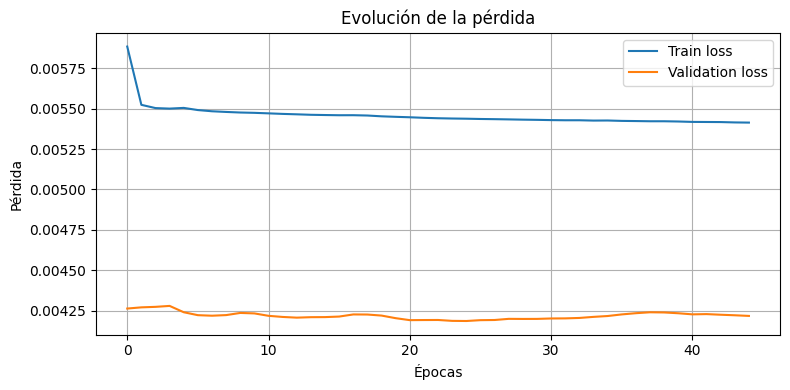

In [5]:
fig = plot_training_curve(hist, show=True)

## Evaluación final (MAE train, val y test)


In [6]:
with mlflow.start_run(run_name=run_name):
    y_pred_train = model.predict(X_train_seq, verbose=0)
    y_pred_val   = model.predict(X_val_seq,   verbose=0)
    y_pred_test  = model.predict(X_test_seq,  verbose=0)

    mae_train = mean_absolute_error(y_train_seq, y_pred_train)
    mae_val   = mean_absolute_error(y_val_seq,   y_pred_val)
    mae_test  = mean_absolute_error(y_test_seq,  y_pred_test)

    for epoch, (train_loss, val_loss) in enumerate(zip(hist.history["loss"], hist.history["val_loss"])):
        mlflow.log_metric("train_loss", train_loss, step=epoch)
        mlflow.log_metric("val_loss",   val_loss,   step=epoch)

    mlflow.log_figure(fig, "plots/loss_curve.png")
    plt.close(fig)

    mlflow.log_param("model_type",         "GRU")
    mlflow.log_param("gru_units",          num_units)
    mlflow.log_param("input_window_size",  input_window_size)
    mlflow.log_param("output_window_size", output_window_size)
    mlflow.log_param("num_features",       X_train_seq.shape[2])
    mlflow.log_param("num_samples",        X_train_seq.shape[0])
    mlflow.log_param("n_params",           model.count_params())
    mlflow.log_param("epochs",             len(hist.history["loss"]))
    mlflow.log_param("batch_size",         batch_size)

    mlflow.log_metric("train_mae", mae_train)
    mlflow.log_metric("val_mae",   mae_val)
    mlflow.log_metric("test_mae",  mae_test)

    mlflow.keras.log_model(model, name="gru_model")

    print(f"MAE train: {mae_train:.6f}")
    print(f"MAE val:   {mae_val:.6f}")
    print(f"MAE test:  {mae_test:.6f}")


2026/05/01 11:47:09 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.


MAE train: 0.005406
MAE val:   0.004185
MAE test:  0.005651


## Grid de ventanas

Mismo barrido que en `regresion_lineal.ipynb`, `mlp_multilayer_perceptron.ipynb` y `rnn-lstm.ipynb` para poder comparar los cuatro modelos celda a celda:

- `input_windows ∈ {5, 10, 30, 90}` días de historia.
- `output_windows ∈ {1, 5, 30, 90}` días de predicción.

Para mantener tiempos razonables usamos `EarlyStopping(patience=10)` y un techo de 100 epochs por combinación.


In [7]:
input_windows  = [5, 10, 30, 90]
output_windows = [1, 5, 30, 90]

results = []

batch_size = 128
num_units  = 64

for in_w in input_windows:
    for out_w in output_windows:
        run_name = f"{EXPERIMENT_NAME}_input{in_w}_output{out_w}"
        existing_runs = mlflow.search_runs(filter_string=f'tags.mlflow.runName = "{run_name}"')
        if not existing_runs.empty:
            mlflow.delete_run(existing_runs.iloc[0].run_id)

        with mlflow.start_run(run_name=run_name):
            X_tr, y_tr, X_val, y_val, X_te, y_te = load_seq_data(in_w, out_w)

            keras.utils.set_random_seed(RANDOM_SEED)
            m = Sequential()
            m.add(Input(shape=(X_tr.shape[1], X_tr.shape[2])))
            m.add(GRU(num_units, return_sequences=False))
            m.add(Dense(y_tr.shape[1]))
            m.compile(loss="mean_absolute_error", optimizer="Adam")

            es = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)
            history = m.fit(
                X_tr, y_tr,
                validation_data=(X_val, y_val),
                epochs=100,
                batch_size=batch_size,
                callbacks=[es],
                verbose=0,
            )

            for epoch, (train_loss, val_loss) in enumerate(zip(history.history["loss"], history.history["val_loss"])):
                mlflow.log_metric("train_loss", train_loss, step=epoch)
                mlflow.log_metric("val_loss",   val_loss,   step=epoch)

            fig = plot_training_curve(history)
            mlflow.log_figure(fig, "plots/loss_curve.png")
            plt.close(fig)

            mae_tr  = mean_absolute_error(y_tr,  m.predict(X_tr,  verbose=0))
            mae_val = mean_absolute_error(y_val, m.predict(X_val, verbose=0))
            mae_te  = mean_absolute_error(y_te,  m.predict(X_te,  verbose=0))

            mlflow.log_param("model_type",         "GRU")
            mlflow.log_param("gru_units",          num_units)
            mlflow.log_param("input_window_size",  in_w)
            mlflow.log_param("output_window_size", out_w)
            mlflow.log_param("n_params",           m.count_params())
            mlflow.log_param("num_samples",        X_tr.shape[0])
            mlflow.log_param("epochs",             len(history.history["loss"]))
            mlflow.log_param("batch_size",         batch_size)

            mlflow.log_metric("train_mae", mae_tr)
            mlflow.log_metric("val_mae",   mae_val)
            mlflow.log_metric("test_mae",  mae_te)

            mlflow.keras.log_model(m, name="gru_model")

            results.append({
                "input_window":  in_w,
                "output_window": out_w,
                "MAE_train":     mae_tr,
                "MAE_test":      mae_te,
            })
            print(f"input={in_w:>3}d, output={out_w:>3}d  ->  MAE train={mae_tr:.6f} | MAE test={mae_te:.6f}")

results_df = pd.DataFrame(results)
results_df


2026/05/01 11:52:06 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.


input=  5d, output=  1d  ->  MAE train=0.011827 | MAE test=0.012312


2026/05/01 11:52:16 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.


input=  5d, output=  5d  ->  MAE train=0.005438 | MAE test=0.005612


2026/05/01 11:52:26 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.


...

2026/05/01 11:56:55 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.


input= 90d, output= 30d  ->  MAE train=0.002175 | MAE test=0.002385


2026/05/01 11:57:32 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.


input= 90d, output= 90d  ->  MAE train=0.001282 | MAE test=0.001299


,input_window,output_window,MAE_train,MAE_test
0,5,1,0.011827,0.012312
1,5,5,0.005438,0.005612
2,5,30,0.002218,0.002380
3,5,90,0.001267,0.001281
4,10,1,0.011820,0.012304
5,10,5,0.005478,0.005640
6,10,30,0.002200,0.002375
7,10,90,0.001295,0.001315
8,30,1,0.011826,0.012313
9,30,5,0.005406,0.005651


## Matrices y heatmaps

In [8]:
mae_train_matrix = results_df.pivot(index="input_window", columns="output_window", values="MAE_train")
mae_test_matrix  = results_df.pivot(index="input_window", columns="output_window", values="MAE_test")

print("MAE — TRAIN")
display(mae_train_matrix)
print("MAE — TEST")
display(mae_test_matrix)
print("Gap (test - train)")
display(mae_test_matrix - mae_train_matrix)

MAE — TRAIN


output_window,1,5,30,90
input_window,,,,
5,0.011827,0.005438,0.002218,0.001267
10,0.011820,0.005478,0.002200,0.001295
30,0.011826,0.005406,0.002219,0.001275
90,0.011862,0.005462,0.002175,0.001282


MAE — TEST


output_window,1,5,30,90
input_window,,,,
5,0.012312,0.005612,0.002380,0.001281
10,0.012304,0.005640,0.002375,0.001315
30,0.012313,0.005651,0.002397,0.001300
90,0.012337,0.005648,0.002385,0.001299


Gap (test - train)


output_window,1,5,30,90
input_window,,,,
5,0.000485,0.000174,0.000161,0.000014
10,0.000484,0.000162,0.000175,0.000020
30,0.000487,0.000245,0.000178,0.000025
90,0.000475,0.000187,0.000210,0.000017


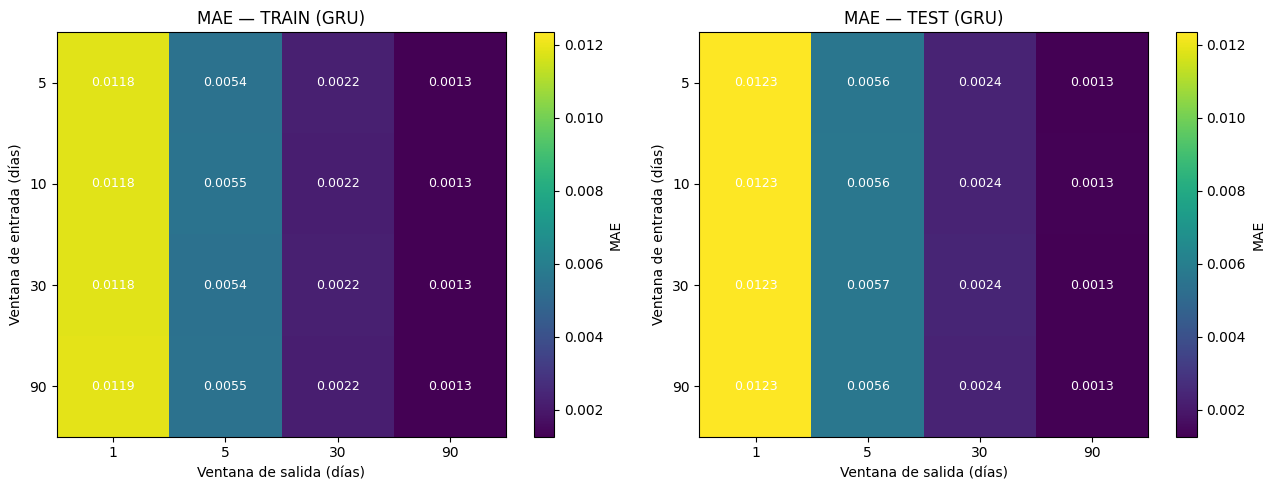

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

vmin = min(mae_train_matrix.values.min(), mae_test_matrix.values.min())
vmax = max(mae_train_matrix.values.max(), mae_test_matrix.values.max())

for ax, matrix, title in [
    (axes[0], mae_train_matrix, "MAE — TRAIN (GRU)"),
    (axes[1], mae_test_matrix,  "MAE — TEST (GRU)"),
]:
    im = ax.imshow(matrix.values, cmap="viridis", aspect="auto", vmin=vmin, vmax=vmax)
    ax.set_xticks(range(len(matrix.columns)))
    ax.set_xticklabels(matrix.columns)
    ax.set_yticks(range(len(matrix.index)))
    ax.set_yticklabels(matrix.index)
    ax.set_xlabel("Ventana de salida (días)")
    ax.set_ylabel("Ventana de entrada (días)")
    ax.set_title(title)
    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            ax.text(j, i, f"{matrix.values[i, j]:.4f}",
                    ha="center", va="center", color="white", fontsize=9)
    plt.colorbar(im, ax=ax, label="MAE")

plt.tight_layout()
plt.show()


## Comparación con el benchmark de regresión lineal

Usamos `compare_to_benchmark` y `plot_benchmark_comparison` de `util.py` para ver, celda a celda del grid, si la GRU mejora o empeora el MAE test respecto a la regresión lineal.

- `delta < 0` (azul): la GRU mejora al benchmark.
- `delta > 0` (rojo): la GRU empeora al benchmark.


,input_window,output_window,MAE_test,MAE_test_benchmark,delta,pct_delta
0,5,1,0.012312,0.012384,-0.000072,-0.581854
1,5,5,0.005612,0.005625,-0.000013,-0.225589
2,5,30,0.002380,0.002340,0.000040,1.695371
3,5,90,0.001281,0.001271,0.000010,0.769920
4,10,1,0.012304,0.012554,-0.000251,-1.995862
5,10,5,0.005640,0.005698,-0.000058,-1.011945
6,10,30,0.002375,0.002358,0.000017,0.703733
7,10,90,0.001315,0.001282,0.000033,2.554427
8,30,1,0.012313,0.012924,-0.000611,-4.726436
9,30,5,0.005651,0.005877,-0.000226,-3.840023


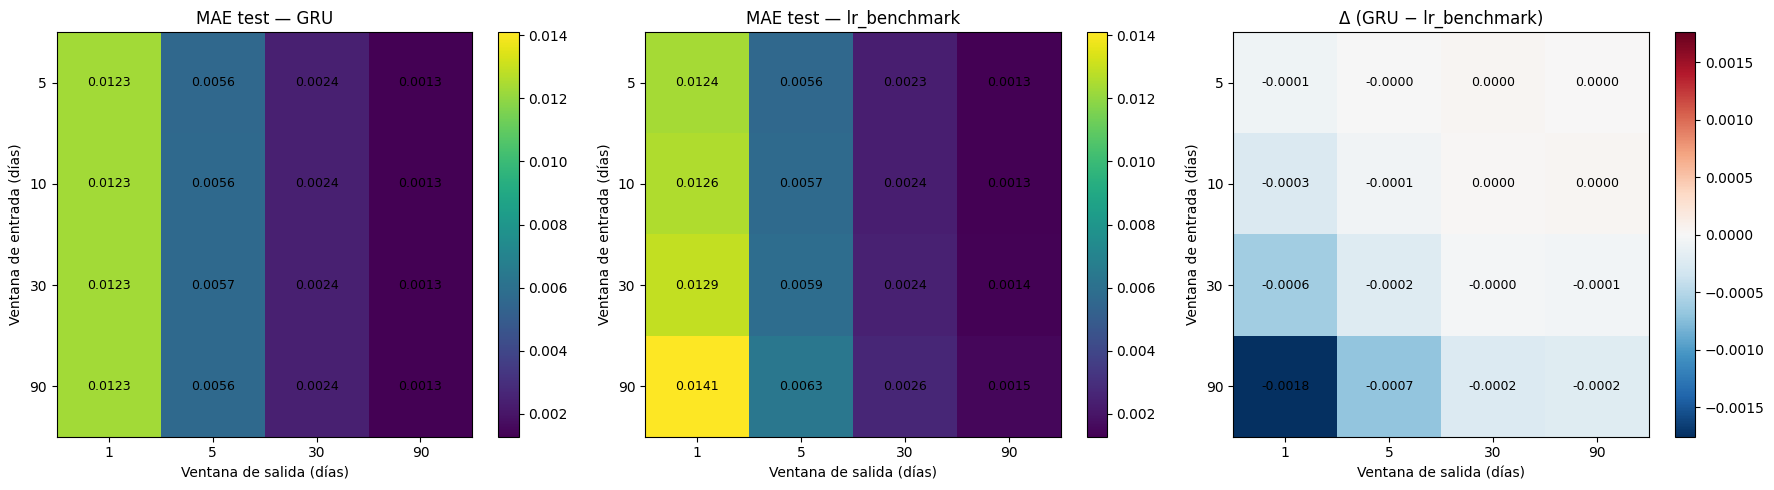

In [10]:
comparison = compare_to_benchmark(results_df, benchmark="lr_benchmark")
display(comparison)

plot_benchmark_comparison(results_df, benchmark="lr_benchmark", model_name="GRU")
plt.show()

## Búsqueda de hiperparámetros

Hasta aquí la arquitectura (1 capa GRU · 64 unidades) y los parámetros de entrenamiento han sido fijos. Buscamos los mejores HPs en **dos etapas** sobre la ventana fija `(input=30, output=5)`:

1. **Arquitectura**: `gru_layers × units × dropout`.
2. **Entrenamiento**: `learning_rate × batch_size`, con la arquitectura ganadora.

Diferencias respecto al MLP:
- En lugar de `activation` (fija en GRU: tanh en la salida + sigmoid en las puertas reset y update), el tercer eje arquitectónico es el **dropout de entrada recurrente**, que regula el overfitting sin cambiar la dinámica de las puertas.
- GRUs apiladas requieren `return_sequences=True` en las capas intermedias.

Reglas clave:
- La selección se hace con **MAE de validación**. El test **no se toca** durante la búsqueda — solo al final con el ganador.
- `EarlyStopping(patience=10, restore_best_weights=True)` en cada entrenamiento.
- `keras.utils.set_random_seed(RANDOM_SEED)` antes de cada fit para que las diferencias entre configuraciones no sean ruido.


In [11]:
import itertools

INPUT_W, OUTPUT_W = 30, 5

X_tr, y_tr, X_val, y_val, X_te, y_te = load_seq_data(INPUT_W, OUTPUT_W)

print(f"Ventana fija: input={INPUT_W}, output={OUTPUT_W}")
print(f"X_tr:  {X_tr.shape}   y_tr:  {y_tr.shape}")
print(f"X_val: {X_val.shape}  y_val: {y_val.shape}")
print(f"X_te:  {X_te.shape}   y_te:  {y_te.shape}")


def build_gru(gru_layers: int, units: int, dropout: float, lr: float = 1e-3):
    """Construye una GRU apilada con N capas recurrentes y compila con Adam+MAE.

    Las capas intermedias usan return_sequences=True para encadenar la secuencia;
    solo la última devuelve el estado oculto final.
    """
    keras.utils.set_random_seed(RANDOM_SEED)
    m = Sequential()
    m.add(Input(shape=(X_tr.shape[1], X_tr.shape[2])))
    for i in range(gru_layers):
        return_seq = (i < gru_layers - 1)
        m.add(GRU(units, return_sequences=return_seq, dropout=dropout))
    m.add(Dense(y_tr.shape[1]))
    m.compile(loss="mean_absolute_error", optimizer=Adam(learning_rate=lr))
    return m


def fit_eval(model, batch_size: int = 128, epochs: int = 200, patience: int = 10, verbose: int = 0):
    """Entrena con EarlyStopping y devuelve MAE_train, MAE_val, MAE_test, history."""
    es = EarlyStopping(monitor="val_loss", patience=patience, restore_best_weights=True)
    h = model.fit(X_tr, y_tr, validation_data=(X_val, y_val), epochs=epochs,
                  batch_size=batch_size, callbacks=[es], verbose=verbose)
    mae_tr  = mean_absolute_error(y_tr,  model.predict(X_tr,  verbose=0))
    mae_val = mean_absolute_error(y_val, model.predict(X_val, verbose=0))
    mae_te  = mean_absolute_error(y_te,  model.predict(X_te,  verbose=0))
    return mae_tr, mae_val, mae_te, h


Ventana fija: input=30, output=5
X_tr:  (13082, 30, 23)   y_tr:  (13082, 23)
X_val: (1453, 30, 23)  y_val: (1453, 23)
X_te:  (1616, 30, 23)   y_te:  (1616, 23)


### Etapa 1 — arquitectura

12 combinaciones: `gru_layers ∈ {1, 2}` · `units ∈ {32, 64, 128}` · `dropout ∈ {0.0, 0.2}`. Adam lr=1e-3, batch=128.

En GRUs apiladas, todas las capas intermedias usan `return_sequences=True` para pasar la secuencia completa a la siguiente capa recurrente; solo la última devuelve el estado final.


In [12]:
arch_grid = list(itertools.product([1, 2], [32, 64, 128], [0.0, 0.2]))

results_arch = []
batch_size_arch = 128

for ll, u, dr in arch_grid:
    run_name = f"{EXPERIMENT_NAME}_arch_layers{ll}_units{u}_drop{dr}_input{INPUT_W}_output{OUTPUT_W}"
    existing_runs = mlflow.search_runs(filter_string=f'tags.mlflow.runName = "{run_name}"')
    if not existing_runs.empty:
        mlflow.delete_run(existing_runs.iloc[0].run_id)

    with mlflow.start_run(run_name=run_name):
        model = build_gru(ll, u, dr, lr=1e-3)
        mae_tr, mae_val, mae_te, h = fit_eval(model, batch_size=batch_size_arch)

        for epoch, (train_loss, val_loss) in enumerate(zip(h.history["loss"], h.history["val_loss"])):
            mlflow.log_metric("train_loss", train_loss, step=epoch)
            mlflow.log_metric("val_loss",   val_loss,   step=epoch)

        fig = plot_training_curve(h)
        mlflow.log_figure(fig, "plots/loss_curve.png")
        plt.close(fig)

        mlflow.log_param("model_type",         "GRU")
        mlflow.log_param("gru_layers",         ll)
        mlflow.log_param("units",              u)
        mlflow.log_param("dropout",            dr)
        mlflow.log_param("learning_rate",      1e-3)
        mlflow.log_param("batch_size",         batch_size_arch)
        mlflow.log_param("input_window_size",  INPUT_W)
        mlflow.log_param("output_window_size", OUTPUT_W)
        mlflow.log_param("num_features",       X_tr.shape[2])
        mlflow.log_param("n_params",           model.count_params())
        mlflow.log_param("epochs",             len(h.history["loss"]))

        mlflow.log_metric("train_mae", mae_tr)
        mlflow.log_metric("val_mae",   mae_val)
        mlflow.log_metric("test_mae",  mae_te)

        mlflow.keras.log_model(model, name="gru_model")

        results_arch.append({
            "gru_layers": ll, "units": u, "dropout": dr,
            "MAE_train": mae_tr, "MAE_val": mae_val, "MAE_test": mae_te,
            "epochs": len(h.history["loss"]), "n_params": model.count_params(),
        })
        print(f"layers={ll} units={u:>3} dropout={dr}  ->  MAE val={mae_val:.6f} | train={mae_tr:.6f} | test={mae_te:.6f} | epochs={len(h.history['loss']):>3}")

results_arch_df = pd.DataFrame(results_arch).sort_values("MAE_val").reset_index(drop=True)
results_arch_df.head(10)


2026/05/01 12:16:08 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.


layers=1 units= 32 dropout=0.0  ->  MAE val=0.004205 | train=0.005481 | test=0.005640 | epochs= 14


2026/05/01 12:16:40 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.


layers=1 units= 32 dropout=0.2  ->  MAE val=0.004166 | train=0.005421 | test=0.005626 | epochs= 68


2026/05/01 12:17:07 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.


...

2026/05/01 12:22:14 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.


layers=2 units=128 dropout=0.0  ->  MAE val=0.004190 | train=0.005413 | test=0.005647 | epochs= 27


2026/05/01 12:23:29 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.


layers=2 units=128 dropout=0.2  ->  MAE val=0.004155 | train=0.005428 | test=0.005612 | epochs= 30


,gru_layers,units,dropout,MAE_train,MAE_val,MAE_test,epochs,n_params
0,2,128,0.2,0.005428,0.004155,0.005612,30,160791
1,2,64,0.2,0.005435,0.004162,0.005615,29,43543
2,1,32,0.2,0.005421,0.004166,0.005626,68,6231
3,1,64,0.2,0.005425,0.004168,0.005629,39,18583
4,2,32,0.2,0.005466,0.004170,0.005606,16,12567
5,1,128,0.2,0.005416,0.004170,0.005630,45,61719
6,2,32,0.0,0.005455,0.004182,0.005627,17,12567
7,2,64,0.0,0.005423,0.004184,0.005648,23,43543
8,1,64,0.0,0.005406,0.004185,0.005651,35,18583
9,1,128,0.0,0.005414,0.004189,0.005645,28,61719


### Etapa 2 — entrenamiento

Fijamos la **arquitectura ganadora** de la etapa 1 y barremos `learning_rate ∈ {1e-2, 1e-3, 1e-4}` · `batch_size ∈ {64, 128, 256}`.

In [13]:
best_arch = results_arch_df.iloc[0]
print(f"Mejor arquitectura: layers={int(best_arch.gru_layers)}  units={int(best_arch.units)}  dropout={best_arch.dropout}")
print(f"  MAE val = {best_arch.MAE_val:.6f}")

train_grid = list(itertools.product([1e-2, 1e-3, 1e-4], [64, 128, 256]))

results_train = []
for lr, bs in train_grid:
    run_name = f"{EXPERIMENT_NAME}_train_lr{lr:.0e}_batch{bs}_input{INPUT_W}_output{OUTPUT_W}"
    existing_runs = mlflow.search_runs(filter_string=f'tags.mlflow.runName = "{run_name}"')
    if not existing_runs.empty:
        mlflow.delete_run(existing_runs.iloc[0].run_id)

    with mlflow.start_run(run_name=run_name):
        model = build_gru(int(best_arch.gru_layers), int(best_arch.units),
                          float(best_arch.dropout), lr=lr)
        mae_tr, mae_val, mae_te, h = fit_eval(model, batch_size=bs)

        for epoch, (train_loss, val_loss) in enumerate(zip(h.history["loss"], h.history["val_loss"])):
            mlflow.log_metric("train_loss", train_loss, step=epoch)
            mlflow.log_metric("val_loss",   val_loss,   step=epoch)

        fig = plot_training_curve(h)
        mlflow.log_figure(fig, "plots/loss_curve.png")
        plt.close(fig)

        mlflow.log_param("model_type",         "GRU")
        mlflow.log_param("gru_layers",         int(best_arch.gru_layers))
        mlflow.log_param("units",              int(best_arch.units))
        mlflow.log_param("dropout",            float(best_arch.dropout))
        mlflow.log_param("learning_rate",      lr)
        mlflow.log_param("batch_size",         bs)
        mlflow.log_param("input_window_size",  INPUT_W)
        mlflow.log_param("output_window_size", OUTPUT_W)
        mlflow.log_param("num_features",       X_tr.shape[2])
        mlflow.log_param("n_params",           model.count_params())
        mlflow.log_param("epochs",             len(h.history["loss"]))

        mlflow.log_metric("train_mae", mae_tr)
        mlflow.log_metric("val_mae",   mae_val)
        mlflow.log_metric("test_mae",  mae_te)

        mlflow.keras.log_model(model, name="gru_model")

        results_train.append({
            "learning_rate": lr, "batch_size": bs,
            "MAE_train": mae_tr, "MAE_val": mae_val, "MAE_test": mae_te,
            "epochs": len(h.history["loss"]),
        })
        print(f"lr={lr:.0e} batch={bs:>3}  ->  MAE val={mae_val:.6f} | train={mae_tr:.6f} | test={mae_te:.6f} | epochs={len(h.history['loss']):>3}")

results_train_df = pd.DataFrame(results_train).sort_values("MAE_val").reset_index(drop=True)
results_train_df


Mejor arquitectura: layers=2  units=128  dropout=0.2
  MAE val = 0.004155


2026/05/01 12:30:54 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.


lr=1e-02 batch= 64  ->  MAE val=0.004294 | train=0.005546 | test=0.005684 | epochs= 13


2026/05/01 12:31:38 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.


lr=1e-02 batch=128  ->  MAE val=0.004320 | train=0.005557 | test=0.005688 | epochs= 16


...

2026/05/01 12:53:34 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.


lr=1e-04 batch=128  ->  MAE val=0.004170 | train=0.005438 | test=0.005595 | epochs= 20


2026/05/01 12:54:14 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.


lr=1e-04 batch=256  ->  MAE val=0.004172 | train=0.005445 | test=0.005592 | epochs= 19


,learning_rate,batch_size,MAE_train,MAE_val,MAE_test,epochs
0,0.0001,64,0.005405,0.004150,0.005612,56
1,0.0010,128,0.005428,0.004155,0.005612,30
2,0.0001,128,0.005438,0.004170,0.005595,20
3,0.0001,256,0.005445,0.004172,0.005592,19
4,0.0010,256,0.005423,0.004183,0.005613,36
5,0.0010,64,0.005472,0.004213,0.005641,26
6,0.0100,64,0.005546,0.004294,0.005684,13
7,0.0100,256,0.005513,0.004303,0.005727,43
8,0.0100,128,0.005557,0.004320,0.005688,16


### Retrain y evaluación final en test

Con los HPs ganadores entrenamos una última vez y evaluamos **por primera vez en test**. Comparamos contra la GRU base del grid de ventanas (`input=30, output=5`) y contra la regresión lineal.


In [14]:
from util import load_benchmark

best_train = results_train_df.iloc[0]
print("Configuración ganadora:")
print(f"  gru_layers    = {int(best_arch.gru_layers)}")
print(f"  units         = {int(best_arch.units)}")
print(f"  dropout       = {float(best_arch.dropout)}")
print(f"  learning_rate = {best_train.learning_rate:.0e}")
print(f"  batch_size    = {int(best_train.batch_size)}")

best_model = build_gru(int(best_arch.gru_layers), int(best_arch.units),
                       float(best_arch.dropout), lr=float(best_train.learning_rate))
mae_tr_best, mae_val_best, mae_te_best, ep_best = fit_eval(
    best_model, batch_size=int(best_train.batch_size)
)

# Referencias para ventana (30, 5)
gru_base_row = results_df[(results_df.input_window == INPUT_W) & (results_df.output_window == OUTPUT_W)].iloc[0]
linreg_bench = load_benchmark("lr_benchmark")
linreg_row   = linreg_bench[(linreg_bench.input_window == INPUT_W) & (linreg_bench.output_window == OUTPUT_W)].iloc[0]

run_name_tuned = f"{EXPERIMENT_NAME}_tuned_input{INPUT_W}_output{OUTPUT_W}"
existing_runs = mlflow.search_runs(filter_string=f'tags.mlflow.runName = "{run_name_tuned}"')
if not existing_runs.empty:
    mlflow.delete_run(existing_runs.iloc[0].run_id)

with mlflow.start_run(run_name=run_name_tuned):
    for epoch, (tl, vl) in enumerate(zip(ep_best.history["loss"], ep_best.history["val_loss"])):
        mlflow.log_metric("train_loss", tl, step=epoch)
        mlflow.log_metric("val_loss",   vl, step=epoch)

    fig_best = plot_training_curve(ep_best)
    mlflow.log_figure(fig_best, "plots/loss_curve.png")
    plt.close(fig_best)

    mlflow.log_param("model_type",         "GRU")
    mlflow.log_param("gru_layers",         int(best_arch.gru_layers))
    mlflow.log_param("units",              int(best_arch.units))
    mlflow.log_param("dropout",            float(best_arch.dropout))
    mlflow.log_param("learning_rate",      float(best_train.learning_rate))
    mlflow.log_param("batch_size",         int(best_train.batch_size))
    mlflow.log_param("input_window_size",  INPUT_W)
    mlflow.log_param("output_window_size", OUTPUT_W)
    mlflow.log_param("n_params",           best_model.count_params())
    mlflow.log_param("epochs",             len(ep_best.history["loss"]))
    mlflow.log_metric("train_mae",         mae_tr_best)
    mlflow.log_metric("val_mae",           mae_val_best)
    mlflow.log_metric("test_mae",          mae_te_best)
    mlflow.keras.log_model(best_model, name="gru_model")

summary = pd.DataFrame([
    {"modelo": "Regresión lineal", "MAE_train": linreg_row.MAE_train,   "MAE_test": linreg_row.MAE_test},
    {"modelo": "GRU base (grid)", "MAE_train": gru_base_row.MAE_train,  "MAE_test": gru_base_row.MAE_test},
    {"modelo": "GRU tuneada",     "MAE_train": mae_tr_best,             "MAE_test": mae_te_best},
])
summary["Δ vs lin.reg."] = summary["MAE_test"] - linreg_row.MAE_test
summary


Configuración ganadora:
  gru_layers    = 2
  units         = 128
  dropout       = 0.2
  learning_rate = 1e-04
  batch_size    = 64


2026/05/01 13:02:32 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.


,modelo,MAE_train,MAE_test,Δ vs lin.reg.
0,Regresión lineal,0.005337,0.005877,0.000000
1,GRU base (grid),0.005406,0.005651,-0.000226
2,GRU tuneada,0.005405,0.005612,-0.000264


### Visualización — top-10 configuraciones

Barras de MAE_val ordenadas para ambas etapas, con MAE_train superpuesto para visualizar el gap de overfitting.

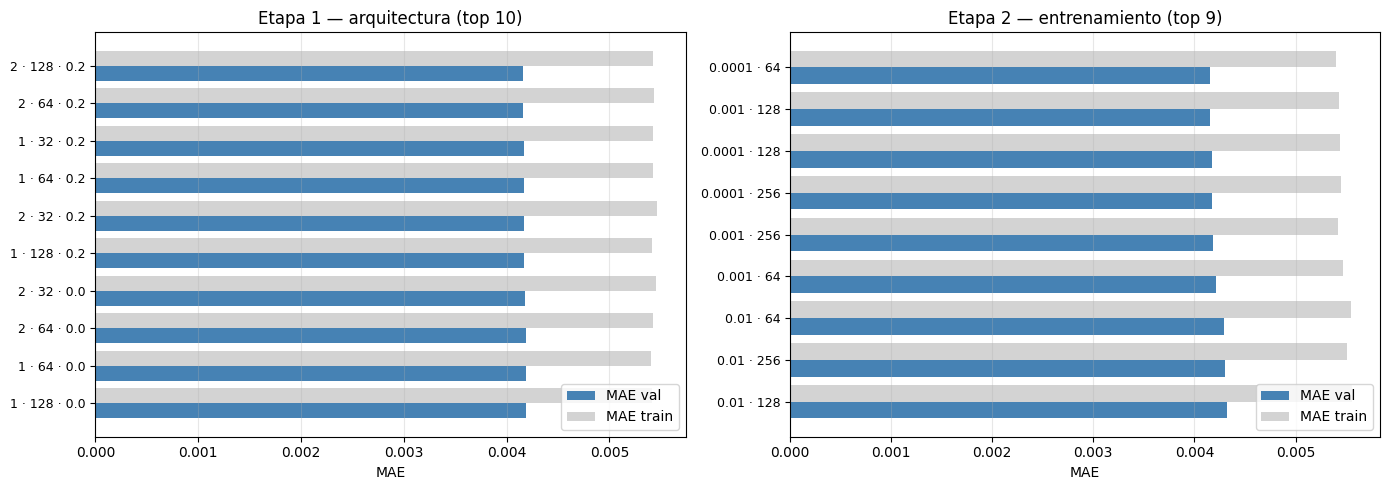

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

def plot_top(ax, df, label_cols, title, top=10):
    top_df = df.head(top).iloc[::-1]
    labels = top_df[label_cols].astype(str).agg(" · ".join, axis=1)
    ypos = np.arange(len(top_df))
    ax.barh(ypos - 0.2, top_df["MAE_val"],   height=0.4, label="MAE val",   color="steelblue")
    ax.barh(ypos + 0.2, top_df["MAE_train"], height=0.4, label="MAE train", color="lightgray")
    ax.set_yticks(ypos); ax.set_yticklabels(labels, fontsize=9)
    ax.set_xlabel("MAE"); ax.set_title(title)
    ax.legend(loc="lower right"); ax.grid(True, axis="x", alpha=0.3)

plot_top(axes[0], results_arch_df,  ["gru_layers", "units", "dropout"],
         "Etapa 1 — arquitectura (top 10)")
plot_top(axes[1], results_train_df, ["learning_rate", "batch_size"],
         f"Etapa 2 — entrenamiento (top {min(10, len(results_train_df))})")

plt.tight_layout(); plt.show()
